# Finding different word meanings using KMeans

## Visualizing phrase-context dendrograms

In [1]:
from selmr import SELMR

# use a SELMR object based on 10000 dbpedia pages
selmr = SELMR(
    path="..//data//dbpedia_10000",
    params={"uncased": True, "lemmatized": False}
)

In [2]:
from selmr import jaccard_distance_matrix
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
from collections import OrderedDict

def plot_dendrogram(c: OrderedDict = None):
    """
    Simple function to plot the dendrogram of 
    """
    distances = jaccard_distance_matrix(c)
    sf_distances = squareform(distances)
    clusters = shc.linkage(
        sf_distances, 
        method='ward', 
        metric="euclidean"
    )
    shc.dendrogram(
        Z=clusters, 
        labels=list(c.keys()), 
        orientation="left", 
        leaf_font_size=7, 
        show_leaf_counts=True
    )
    plt.savefig('dendrogram.png', bbox_inches='tight')
    plt.show()
    

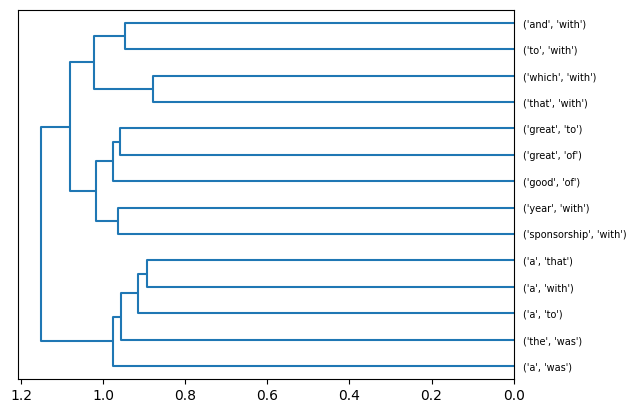

In [3]:
phrase = "deal"

c = selmr.phrase_base_contexts(phrase=phrase)

plot_dendrogram(c)

For illustrative purposes, this shows only the base contexts (contexts with one word on the left side and one word on the right side of the context). The branches of the first four lines show the contexts in which the word 'deal' is used as a verb ('to deal with' and 'that deal with'). In the lower five branches the word is used as a common noun ('a deal with' and 'a deal was'). In the middle general branch the word is used in the contexts of 'great deal to' or 'good deal of' (also a noun but with a different usage).

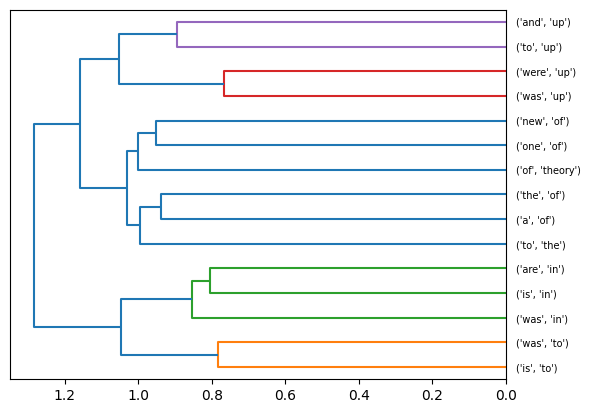

In [4]:
phrase = "set"

c = selmr.phrase_base_contexts(phrase=phrase, topn=25)

plot_dendrogram(c)

The word 'set' is a bit more complicated. The four leaves at the stop identify variations of the use of the verb 'to set up'. The four leaves at the bottom identify 'to set in' and 'to set to'. The middle leaves use the word 'set' as a noun (with one exception): set theory, a set of, one set of, etc.

## Clustering word meanings with KMeans

In [5]:
phrase = "deal"

word_contexts = selmr.phrase_base_contexts(phrase=phrase, topn=25)

distances = jaccard_distance_matrix(word_contexts)

weights = [selmr._contexts[context][phrase] for context, values in word_contexts.items()]

In [6]:
from sklearn.cluster import KMeans
import pandas as pd
from collections import defaultdict

n_clusters = 3

a = KMeans(
    n_clusters=n_clusters,
    max_iter=10000,
    n_init=250,
    tol=1e-10,
    random_state=0
).fit(distances, weights)

for cluster in range(0, n_clusters):
    base_contexts = pd.Series(word_contexts.keys())[a.labels_==cluster].values
    print("Cluster "+str(cluster)+": base_clusters = "+str(base_contexts))

Cluster 0: base_clusters = [('a', 'with') ('the', 'was') ('a', 'to') ('a', 'was') ('a', 'that')]
Cluster 1: base_clusters = [('great', 'of') ('good', 'of') ('sponsorship', 'with')]
Cluster 2: base_clusters = [('to', 'with') ('that', 'with') ('and', 'with')]


In [7]:
# add underlying contexts to base clusters

clustered_dict = defaultdict(dict)
for cluster in range(0, n_clusters):
    base_contexts = pd.Series(word_contexts.keys())[a.labels_==cluster].values
    cluster_contexts = set(base_contexts)
    for context in base_contexts:
        sub_contexts = [
            c for c in selmr.contexts(phrase, topn=None)
            if (c[0].count(" ")>=1 or c[1].count(" ")>=1)
            and (context[0] == c[0].split(" ")[-1] and context[1] == c[1].split(" ")[0])
            and "SENTEND" not in c[1] and "SENTSTART" not in c[0]
        ]
        cluster_contexts.update(sub_contexts)
    clustered_dict[phrase][cluster] = cluster_contexts

## Splitting the phrase-context multisets

In [8]:
from selmr import Multiset

for cluster in range(0, n_clusters):
    new_word = phrase+"-"+str(cluster+1)
    selmr._phrases[new_word] = Multiset()
    for context in clustered_dict[phrase][cluster]:
        count = selmr._phrases[phrase][context]
        del selmr._phrases[phrase][context]
        selmr._phrases[new_word][context] = count
        del selmr._contexts[context][phrase]
        selmr._contexts[context][new_word] = count

In [9]:
# now we can look up the most similar words of the new phrases

for cluster in range(0, n_clusters):
    new_phrase = phrase+"-"+str(cluster+1)
    print(new_phrase+": \n  "+str(selmr.most_similar(new_phrase, topn=5, topcontexts=15)))
    print("  "+str(selmr.contexts(new_phrase, topn=5)))

deal-1: 
  Multiset({'deal-1': 15, 'treaty': 10, 'truce': 8, 'contract': 8, 'pact': 7})
  Multiset({('a', 'with'): 225, ('the', 'was'): 87, ('a', 'to'): 53, ('sentstart the', 'was'): 43, ('a', 'with the'): 43})
deal-2: 
  Multiset({'deal-2': 15, 'number': 6, 'part': 5, 'example': 4, 'variety': 4})
  Multiset({('great', 'of'): 649, ('a great', 'of'): 634, ('good', 'of'): 86, ('a good', 'of'): 83, ('great', 'of time'): 31})
deal-3: 
  Multiset({'deal-3': 15, 'work': 8, 'compete': 8, 'do': 7, 'cope': 7})
  Multiset({('to', 'with'): 974, ('to', 'with the'): 336, ('had to', 'with'): 71, ('how to', 'with'): 48, ('that', 'with'): 45})
